In [1]:
import uproot
import dask_awkward as dak
import awkward as ak
import zfit
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mplhep as hep
from dask.diagnostics import ProgressBar

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
plt.style.use(hep.style.CMS)

In [3]:
mc_files = {"/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_psi2s_2022.root": "Events"}
df = uproot.dask(mc_files)

In [4]:
def get_perfect_b0_matter_mask(df):
    PDG_B0        =  511
    PDG_KSTAR     =  313
    PDG_KAON_plus =  321
    PDG_PION_neg  = -211
    PDG_PHOTON    =  22
    PDG_JPSI      =  100443
    PDG_MUON_plus = -13
    PDG_MUON_neg  =  13

    pdg_ids = df["BPHGenPart_pdgId"]
    mom_idx = df["BPHGenPart_genPartIdxMother"]
    
    mu1_idx  = df["BPH_1Muon_genPartIdx"]
    mu2_idx  = df["BPH_2Muon_genPartIdx"]
    trk1_idx = df["Trk1_genPartIdx"]
    trk2_idx = df["Trk2_genPartIdx"]

    mu1_pdg  = pdg_ids[ak.mask(mu1_idx, mu1_idx >= 0)]
    mu2_pdg  = pdg_ids[ak.mask(mu2_idx, mu2_idx >= 0)]
    trk1_pdg = pdg_ids[ak.mask(trk1_idx, trk1_idx >= 0)]
    trk2_pdg = pdg_ids[ak.mask(trk2_idx, trk2_idx >= 0)]

    flavor_match = (trk1_pdg == PDG_KAON_plus) & (trk2_pdg == PDG_PION_neg) & \
                   (mu1_pdg == PDG_MUON_plus) & (mu2_pdg == PDG_MUON_neg)

    mom_trk1_idx = mom_idx[ak.mask(trk1_idx, trk1_idx >= 0)]
    mom_trk2_idx = mom_idx[ak.mask(trk2_idx, trk2_idx >= 0)]
    mom_trk1_pdg = pdg_ids[ak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    mom_trk2_pdg = pdg_ids[ak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]

    match_kstar = (mom_trk1_idx == mom_trk2_idx) & (mom_trk1_idx >= 0) & (mom_trk2_idx >= 0) & \
                  (mom_trk1_pdg == PDG_KSTAR) & (mom_trk2_pdg == PDG_KSTAR)

    gmom_trk1_idx = mom_idx[ak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    gmom_trk2_idx = mom_idx[ak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]    
    gmom_trk1_pdg = pdg_ids[ak.mask(gmom_trk1_idx, gmom_trk1_idx >= 0)]
    gmom_trk2_pdg = pdg_ids[ak.mask(gmom_trk2_idx, gmom_trk2_idx >= 0)]

    match_kstar_to_b0 = (gmom_trk1_idx == gmom_trk2_idx) & (gmom_trk1_idx >= 0) & (gmom_trk2_idx >= 0) & \
                        (gmom_trk1_pdg == PDG_B0) & (gmom_trk2_pdg == PDG_B0)

    mom_mu1_idx = mom_idx[ak.mask(mu1_idx, mu1_idx >= 0)]
    mom_mu2_idx = mom_idx[ak.mask(mu2_idx, mu2_idx >= 0)]
    gmom_mu1_idx = mom_idx[ak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    gmom_mu2_idx = mom_idx[ak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]

    mom_mu1_pdg = pdg_ids[ak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    mom_mu2_pdg = pdg_ids[ak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]    
    gmom_mu1_pdg = pdg_ids[ak.mask(gmom_mu1_idx, gmom_mu1_idx >= 0)]
    gmom_mu2_pdg = pdg_ids[ak.mask(gmom_mu2_idx, gmom_mu2_idx >= 0)]

    ggmom_mu1_idx = mom_idx[ak.mask(gmom_mu1_idx, gmom_mu1_idx >= 0)]
    ggmom_mu2_idx = mom_idx[ak.mask(gmom_mu2_idx, gmom_mu2_idx >= 0)]    
    ggmom_mu1_pdg = pdg_ids[ak.mask(ggmom_mu1_idx, ggmom_mu1_idx >= 0)]
    ggmom_mu2_pdg = pdg_ids[ak.mask(ggmom_mu2_idx, ggmom_mu2_idx >= 0)]

    mu1_match = (mom_mu1_idx == gmom_trk1_idx) | \
                ((mom_mu1_pdg == PDG_PHOTON) & (gmom_mu2_pdg == PDG_JPSI) & (ggmom_mu1_idx == gmom_trk1_idx))

    mu2_match = (mom_mu2_idx == gmom_trk1_idx) | \
            ((mom_mu2_pdg == PDG_PHOTON) & (gmom_mu2_pdg == PDG_JPSI) & (ggmom_mu2_idx == gmom_trk1_idx))
    truth_match_final = flavor_match & match_kstar & match_kstar_to_b0 & mu1_match & mu2_match

    return ak.fill_none(truth_match_final, False)

In [5]:
def apply_selection(df):
    mask = (        
        # --- Ressonância (J/psi) ---
        (((df['MuMu_mass'] > 3.3) & (df['MuMu_mass'] < 4.05)) &
        
        # --- Seleção do K*0 (892) ---
        (abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - 0.892) <= 0.150) & 
        (abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - 0.892) <= 0.150) & 
        (df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] < df['BToTrkTrkMuMu_fit_ditrack_mass_piK']) & 
        
        # --- Aceitação dos Múons ---
        (df['BPH_1Muon_pt'] > 4.0) & (df['BPH_2Muon_pt'] > 4.0) & 
        (abs(df['BPH_1Muon_eta']) < 2.5) & (abs(df['BPH_2Muon_eta']) < 2.5)
    ))
    
    return ak.fill_none(mask, False)

In [6]:
with ProgressBar():
    rare_mask = get_perfect_b0_matter_mask(df)
    kin_mask = apply_selection(df)
    final_mask = rare_mask 
    clean_mass = df["BToTrkTrkMuMu_fit_mass_Kpi"][final_mask]

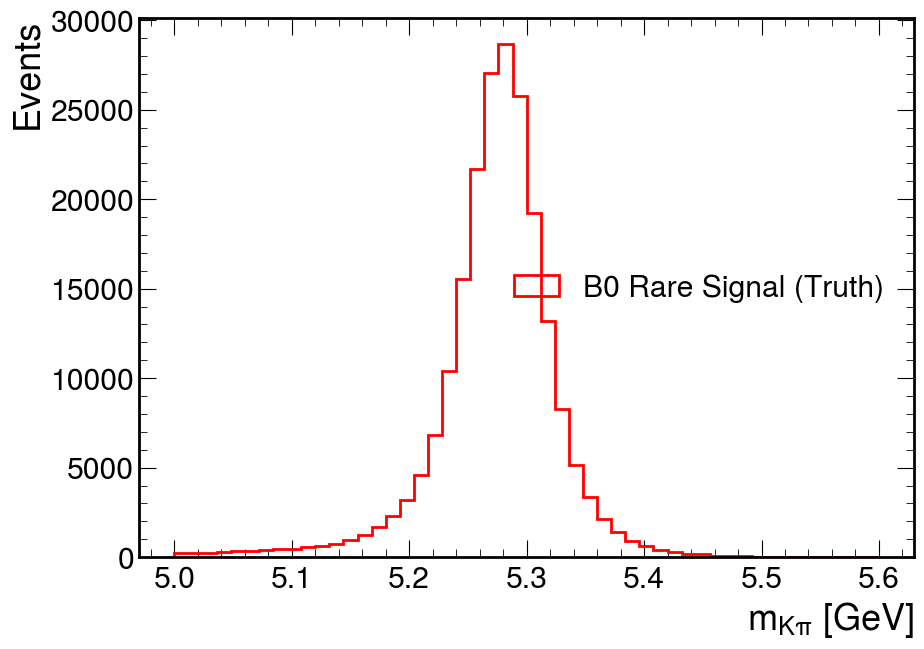

In [7]:
plt.figure(figsize=(10, 7))
data = ak.to_numpy(ak.flatten(clean_mass.compute(), axis=None))
plt.hist(data, bins=50, histtype='step',range=(5.0, 5.6), lw=2, color='red', label='B0 Rare Signal (Truth)')
plt.xlabel(r"$m_{K\pi}$ [GeV]")
plt.ylabel("Events")
plt.legend()
plt.show()

In [8]:
mass_min, mass_max = 5.0, 5.6
obs = zfit.Space("m_b", limits=(mass_min, mass_max))

In [9]:
mu    = zfit.Parameter("mu", 5.279, 5.2, 5.4)
sigma = zfit.Parameter("sigma", 0.02, 0.001, 0.1)
alphal = zfit.Parameter("alphal", 1.5, 0.1, 5.0)
nl     = zfit.Parameter("nl", 2.0, 0.1, 30.0)
alphar = zfit.Parameter("alphar", 1.5, 0.1, 5.0)
nr     = zfit.Parameter("nr", 2.0, 0.1, 30.0)

In [10]:
model = zfit.pdf.DoubleCB(obs=obs, mu=mu, sigma=sigma, 
                          alphal=alphal, nl=nl, alphar=alphar, nr=nr)

In [11]:
zfit_data = zfit.Data.from_numpy(obs=obs, array=data)
nll = zfit.loss.UnbinnedNLL(model=model, data=zfit_data)
minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(nll)

In [12]:
result.errors()
print(f"Fit Convergiu? {result.converged}")
print(result)

Fit Convergiu? True
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.physics.DoubleCB'>  params=[alphal, alphar, mu, nl, nr, sigma]] data=[<zfit.Data: Data obs=('m_b',) shape=(210422, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │  edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.0002 │       -351736.57 | -6915.456 │
╘═════════╧═════════════╧══════════════════╧════════╧══════════════════════════════╛

Parameters
name      value  (rounded)               errors    at limit
------  ------------------  -------------------  ----------
mu                  5.2795  - 0.0001   +0.00011       False
sigma            0.0310739  -0.00015   +0.00015       False
alphal             1.31315  -  0.015   +  0.015       False
nl            

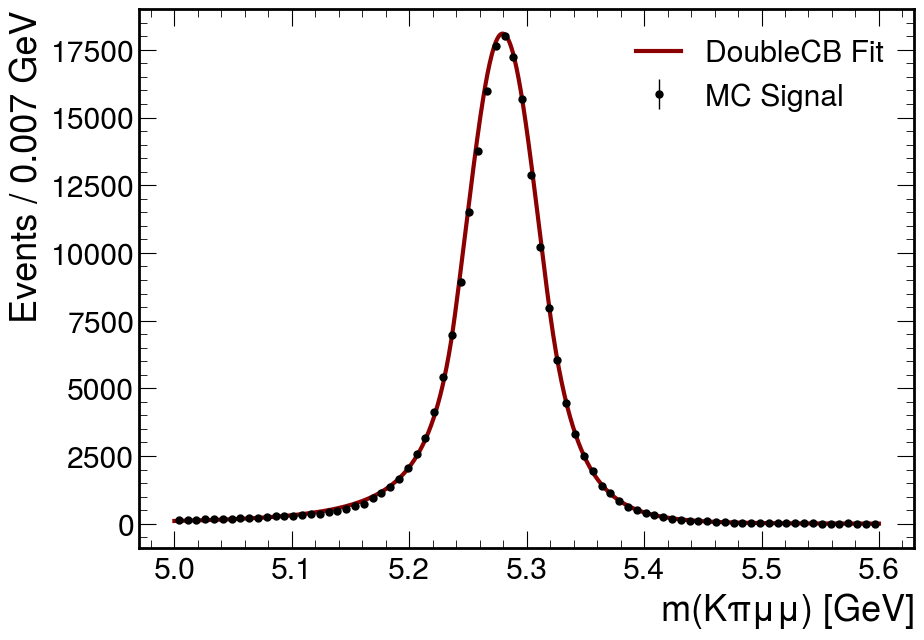

In [13]:
plt.figure(figsize=(10, 7))
num_bins = 80
counts, bin_edges = np.histogram(data, bins=num_bins, range=(mass_min, mass_max))
bin_width = (mass_max - mass_min) / num_bins

x_plot = np.linspace(mass_min, mass_max, 1000)
y_plot = model.pdf(x_plot).numpy() * len(data) * bin_width

hep.histplot(counts, bins=bin_edges, color='black', label='MC Signal', histtype='errorbar')
plt.plot(x_plot, y_plot, color='darkred', lw=3, label='DoubleCB Fit')

plt.xlabel(r"$m(K\pi\mu\mu)$ [GeV]")
plt.ylabel(f"Events / {bin_width:.3f} GeV")
plt.legend()
plt.show()

In [14]:
cov_matrix = result.covariance()
print("Matriz de Covariância:")
print(cov_matrix)

Matriz de Covariância:
[[ 1.11812892e-08 -9.86731648e-10 -5.21231264e-07  2.29265666e-06
   4.35983380e-07 -2.46409684e-05]
 [-9.86731648e-10  2.38509411e-08  1.50618703e-06 -4.64900411e-06
   1.74609889e-06 -4.81953014e-05]
 [-5.21231264e-07  1.50618703e-06  2.15478912e-04 -9.60901989e-04
   9.82156715e-05 -2.37613538e-03]
 [ 2.29265666e-06 -4.64900411e-06 -9.60901989e-04  5.40131966e-03
  -2.75280016e-04  5.86001587e-03]
 [ 4.35983380e-07  1.74609889e-06  9.82156715e-05 -2.75280016e-04
   2.61896034e-04 -1.28528131e-02]
 [-2.46409684e-05 -4.81953014e-05 -2.37613538e-03  5.86001587e-03
  -1.28528131e-02  9.49816234e-01]]


In [15]:
nll_value = result.fmin
print(f"Log-Likelihood mínimo: {nll_value:.2f}")


counts, bin_edges = np.histogram(data, bins=80, range=(5.0, 5.6))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

expected_counts = model.pdf(bin_centers).numpy() * len(data) * bin_width
mask = counts > 0
chi2 = np.sum(((counts[mask] - expected_counts[mask])**2) / expected_counts[mask])
n_params = len(result.params)
ndf = len(counts) - n_params

print(f"Chi2: {chi2:.2f}")
print(f"NDF: {ndf}")
print(f"Chi2/NDF: {chi2/ndf:.2f}")

Log-Likelihood mínimo: -351736.57
Chi2: 341.00
NDF: 74
Chi2/NDF: 4.61


In [16]:
edm = result.edm
print(f"EDM (Estimated Distance to Minimum): {edm:.6f}")

EDM (Estimated Distance to Minimum): 0.000204


In [17]:
res_raw = result.info['original']
fmin = res_raw.fmin if hasattr(res_raw, 'fmin') else res_raw

print(f"--- STATUS DO MINUIT (covQ) ---")
print(f"1. Fit Convergiu (Migrad):    {fmin.is_valid}")
print(f"2. Matriz de Covariância:     {fmin.has_covariance}")
print(f"3. Matriz é Precisa (covQ=3): {fmin.has_accurate_covar}")
print(f"4. EDM (Distância ao Mínimo): {fmin.edm:.6f}")

--- STATUS DO MINUIT (covQ) ---
1. Fit Convergiu (Migrad):    True
2. Matriz de Covariância:     True
3. Matriz é Precisa (covQ=3): True
4. EDM (Distância ao Mínimo): 0.000204
